# ICA10 — Assessing impact of changing vertical resolution 

This notebook is a streamlined introduction to reading hourly output from 72-hr simulations of Hurricane Harvey focused on understanding the impact of microphysics schemes.  Examples are provided for:
- reading in the maximum 10-m wind speed from csv files generated using ncks, 
- for plotting the track (based on minimum sea level pressure), and
- for contouring total precipitation (based on RAINC + RAINNC).

Julie.Lundquist@JHU.edu
2026 March (updated from 2023 version)




In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import xarray as xr
import re

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

from pathlib import Path
import glob
import os

from matplotlib.axes import Axes # Makes the color bar easier to work with
from mpl_toolkits.axes_grid1 import make_axes_locatable # Color bar location
import matplotlib.ticker as mticker
from wrf import getvar, latlon_coords
from netCDF4 import Dataset


from datetime import datetime


from matplotlib.colors import ListedColormap, BoundaryNorm # Because I'm particular about color tables
from matplotlib.colors import Normalize # Because I'm particular about color tables
from matplotlib.colors import TwoSlopeNorm # to help normalize map factors so color table is centered on zero
 

print("Imports OK")

Imports OK


In [2]:
# Define where the current workign directory is
os.chdir("/home/jlundqui/EN530.462/AtmosphericModelingLab/ICA10")


In [3]:
# ---------------- USER SETTINGS ----------------
PARENT_DIR = Path("/scratch/alpine/jlundqui/NWP/ICA10")

# Settings for the max wind speed:
# Modify these based on your choices:
CASE_DIRS = {
    "mp_physics_01": "Kessler",
    "mp_physics_04": "WSM5",
    "mp_physics_08": "Thompson",
}

CSV_NAME = "max_wspd10_timeseries.csv"
OUT_PNG = "compare_max_wspd10_timeseries.png"

# For the contour plots
SIM_DIRS = {
    "mp_physics_01": PARENT_DIR / "mp_physics_01",
    "mp_physics_04": PARENT_DIR / "mp_physics_04",
    "mp_physics_08": PARENT_DIR / "mp_physics_08",
}

FILE_GLOB = "wrfout_d02_*"
OUT_DIR =  Path.cwd() / "wspd10_3panel_d02"
OUT_DIR.mkdir(parents=True, exist_ok=True)

USE_LATLON = True
VMIN = 0.0
VMAX = 35.0
NLEVELS = 15
CMAP = "viridis"
DPI = 150

# ----------------------------------------------


## Read in the max wind speed and compare the three simulations

In [4]:
def read_max_wspd_csv(csv_path: Path, label: str) -> pd.DataFrame:
    """
    Read one max_wspd10_timeseries.csv file and return a DataFrame
    with columns: time, <label>.
    """
    df = pd.read_csv(csv_path)

    # Parse time column
#     df["time"] = pd.to_datetime(df["time"])
    df["time"] = pd.to_datetime(df["time"], format="%Y-%m-%d_%H:%M:%S")

    # Force numeric in case of any odd formatting
    df["max_wspd10"] = pd.to_numeric(df["max_wspd10"], errors="coerce")

    # Keep only needed columns and rename value column to case label
    df = df[["time", "max_wspd10"]].rename(columns={"max_wspd10": label})

    return df


# Read all three files
dfs = []
for subdir, label in CASE_DIRS.items():
    csv_path = PARENT_DIR / subdir / CSV_NAME

    if not csv_path.exists():
        print(f"[WARN] Missing file: {csv_path}")
        continue

    df = read_max_wspd_csv(csv_path, label)
    dfs.append(df)
    print(f"[OK] Read {csv_path}")

if not dfs:
    raise FileNotFoundError("No CSV files were found.")

# Merge on time
df_all = dfs[0]
for df in dfs[1:]:
    df_all = df_all.merge(df, on="time", how="outer")

df_all = df_all.sort_values("time")

print(df_all.head())



[OK] Read /scratch/alpine/jlundqui/NWP/ICA10/mp_physics_01/max_wspd10_timeseries.csv
[OK] Read /scratch/alpine/jlundqui/NWP/ICA10/mp_physics_04/max_wspd10_timeseries.csv
[OK] Read /scratch/alpine/jlundqui/NWP/ICA10/mp_physics_08/max_wspd10_timeseries.csv
                 time    Kessler       WSM5   Thompson
0 2017-08-25 00:00:00  38.574455  38.574455  38.574455
1 2017-08-25 01:00:00  38.257744  36.817619  37.039570
2 2017-08-25 02:00:00  46.985241  43.694756  44.388111
3 2017-08-25 03:00:00  44.277870  42.613880  42.605324
4 2017-08-25 04:00:00  38.674381  42.533291  39.536087


[OK] Saved figure to compare_max_wspd10_timeseries.png


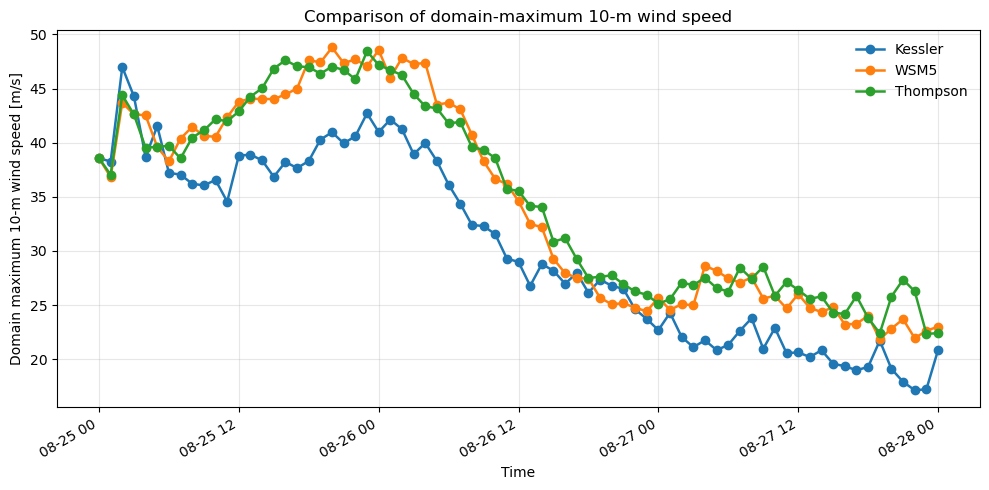

In [5]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))

for label in CASE_DIRS.values():
    if label in df_all.columns:
        ax.plot(df_all["time"], df_all[label], marker="o", linewidth=1.8, label=label)

ax.set_xlabel("Time")
ax.set_ylabel("Domain maximum 10-m wind speed [m/s]")
ax.set_title("Comparison of domain-maximum 10-m wind speed")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

fig.autofmt_xdate()
fig.tight_layout()

fig.savefig(OUT_PNG, dpi=200)
print(f"[OK] Saved figure to {OUT_PNG}")

plt.show()

## Handy functions for plotting 2D fields

In [23]:
def get_2d_field(da):
    """Return a 2D numpy array from a WRF field that may have a Time dimension."""
    arr = da.values
    if arr.ndim == 3:
        return arr[0, :, :]
    elif arr.ndim == 2:
        return arr
    else:
        raise ValueError(f"Unexpected number of dimensions: {arr.ndim}")


def get_latlon(ds):
    """Get 2D lat/lon arrays from WRF output."""
    if "XLAT" in ds.variables and "XLONG" in ds.variables:
        lat = get_2d_field(ds["XLAT"])
        lon = get_2d_field(ds["XLONG"])
    elif "lat" in ds.variables and "lon" in ds.variables:
        lat = get_2d_field(ds["lat"])
        lon = get_2d_field(ds["lon"])
    else:
        raise KeyError("Could not find XLAT/XLONG or lat/lon in dataset.")
    return lat, lon


def get_wspd10(ds):
    """Compute 10-m wind speed from U10 and V10."""
    u10 = get_2d_field(ds["U10"])
    v10 = get_2d_field(ds["V10"])
    return np.sqrt(u10**2 + v10**2)


def extract_valid_time_from_name(path):
    """Use the filename suffix as the valid time string."""
    # e.g. wrfout_d02_2017-08-25_00:00:00
    return path.name.replace("wrfout_d01_", "")




## Check to see where min SLP moves:

[OK] Saved /scratch/alpine/jlundqui/NWP/ICA10/mp_physics_08/min_slp_track_d01.csv
[OK] Saved /scratch/alpine/jlundqui/NWP/ICA10/mp_physics_08/min_slp_track_d01.png


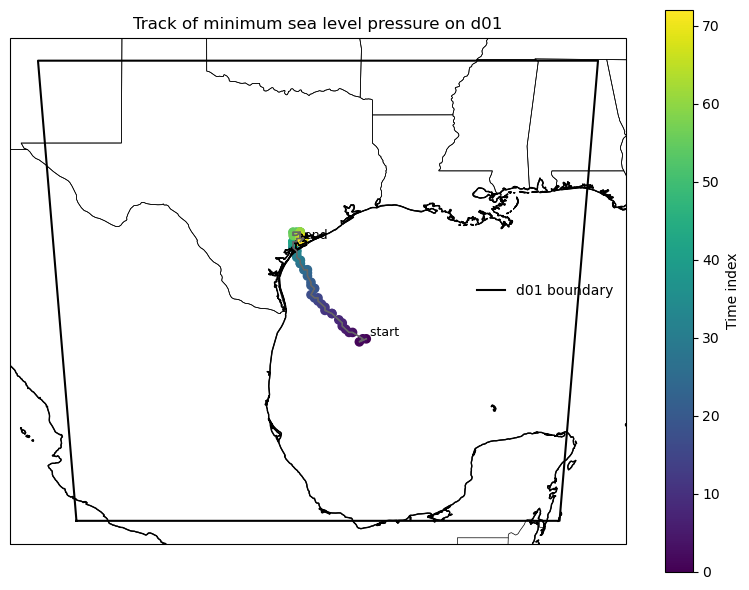

In [6]:
# In d01


# ---------------- USER SETTINGS ----------------
WRF_DIR = Path("/scratch/alpine/jlundqui/NWP/ICA10/mp_physics_08")
# WRF_DIR = Path("/scratch/alpine/jlundqui/NWP/ICA10/new_grid")
FILE_GLOB = "wrfout_d01_*"

OUT_CSV = WRF_DIR / "min_slp_track_d01.csv"
OUT_PNG = WRF_DIR / "min_slp_track_d01.png"
# ----------------------------------------------


def get_time_from_filename(path):
    """Extract valid time from wrfout filename."""
    return pd.to_datetime(path.name.replace("wrfout_d01_", ""),
                          format="%Y-%m-%d_%H:%M:%S")


files = sorted(WRF_DIR.glob(FILE_GLOB))
if not files:
    raise FileNotFoundError(f"No files found matching {FILE_GLOB} in {WRF_DIR}")

rows = []

# Read lat/lon grid from first file
with Dataset(files[0]) as ds0:
    slp0 = getvar(ds0, "slp", timeidx=0)   # hPa
    lats, lons = latlon_coords(slp0)
    lat2d = np.asarray(lats)
    lon2d = np.asarray(lons)

for f in files:
    t = get_time_from_filename(f)

    with Dataset(f) as ds:
        slp = getvar(ds, "slp", timeidx=0)   # hPa
        slp2d = np.asarray(slp)

        jmin, imin = np.unravel_index(np.nanargmin(slp2d), slp2d.shape)
        slp_min = float(slp2d[jmin, imin])

        rows.append({
            "time": t,
            "j": int(jmin),
            "i": int(imin),
            "lat": float(lat2d[jmin, imin]),
            "lon": float(lon2d[jmin, imin]),
            "min_slp_hpa": slp_min,
        })

df = pd.DataFrame(rows).sort_values("time")
df.to_csv(OUT_CSV, index=False)
print(f"[OK] Saved {OUT_CSV}")

# ---------------- Plot map of track ----------------
# fig, ax = plt.subplots(figsize=(8, 6))
fig, ax = plt.subplots(
    figsize=(8, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.coastlines(resolution="10m", linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5)

# Domain boundary from grid corners

transform=ccrs.PlateCarree()
ax.plot(
    [lon2d[0, 0], lon2d[0, -1], lon2d[-1, -1], lon2d[-1, 0], lon2d[0, 0]],
    [lat2d[0, 0], lat2d[0, -1], lat2d[-1, -1], lat2d[-1, 0], lat2d[0, 0]],
    color="k", linewidth=1.5, label="d01 boundary",
    transform=ccrs.PlateCarree()
)

# ax.plot(
#     [lon2d[0, 0], lon2d[0, -1], lon2d[-1, -1], lon2d[-1, 0], lon2d[0, 0]],
#     [lat2d[0, 0], lat2d[0, -1], lat2d[-1, -1], lat2d[-1, 0], lat2d[0, 0]],
#     color="k", linewidth=1.5, label="d02 boundary"
# )

# Track
ax.plot(
    df["lon"], df["lat"],
    color="0.4", linewidth=1.0,
    transform=ccrs.PlateCarree()
)

sc = ax.scatter(
    df["lon"], df["lat"],
    c=np.arange(len(df)),
    s=35,
    cmap="viridis",
    transform=ccrs.PlateCarree()
)

# sc = ax.scatter(
#     df["lon"], df["lat"],
#     c=np.arange(len(df)),
#     s=35,
#     cmap="viridis"
# )
ax.plot(df["lon"], df["lat"], color="0.4", linewidth=1.0)

# Label start/end
ax.text(df["lon"].iloc[0],  df["lat"].iloc[0],  " start", fontsize=9, va="bottom")
ax.text(df["lon"].iloc[-1], df["lat"].iloc[-1], " end",   fontsize=9, va="bottom")
ax.coastlines(resolution="10m", linewidth=0.8)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Track of minimum sea level pressure on d01")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Time index")

ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()

fig.savefig(OUT_PNG, dpi=200)
print(f"[OK] Saved {OUT_PNG}")

plt.show()

[OK] Saved /scratch/alpine/jlundqui/NWP/ICA10/mp_physics_08/min_slp_track_d02.csv
[OK] Saved /scratch/alpine/jlundqui/NWP/ICA10/mp_physics_08/min_slp_track_d02.png


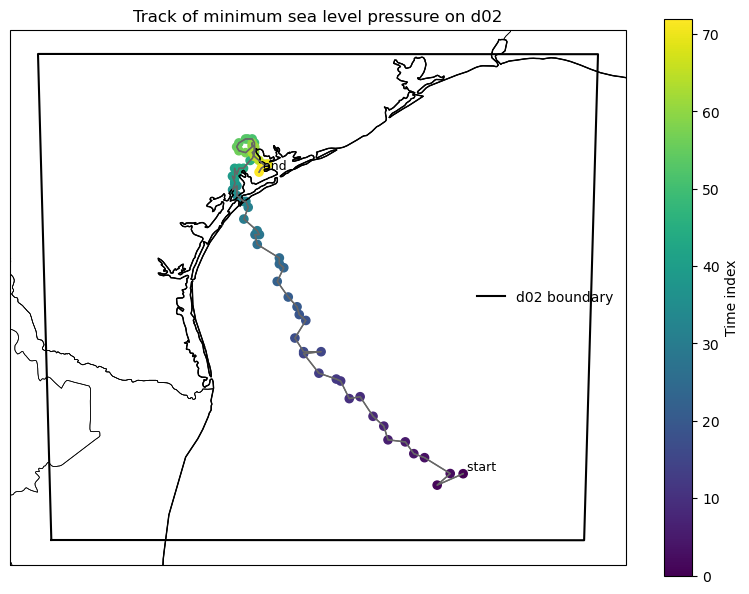

In [7]:
# In d02

# ---------------- USER SETTINGS ----------------
WRF_DIR = Path("/scratch/alpine/jlundqui/NWP/ICA10/mp_physics_08")
# WRF_DIR = Path("/scratch/alpine/jlundqui/NWP/ICA10/new_grid")
FILE_GLOB = "wrfout_d02_*"

OUT_CSV = WRF_DIR / "min_slp_track_d02.csv"
OUT_PNG = WRF_DIR / "min_slp_track_d02.png"
# ----------------------------------------------


def get_time_from_filename(path):
    """Extract valid time from wrfout filename."""
    return pd.to_datetime(path.name.replace("wrfout_d02_", ""),
                          format="%Y-%m-%d_%H:%M:%S")


files = sorted(WRF_DIR.glob(FILE_GLOB))
if not files:
    raise FileNotFoundError(f"No files found matching {FILE_GLOB} in {WRF_DIR}")

rows = []

# Read lat/lon grid from first file
with Dataset(files[0]) as ds0:
    slp0 = getvar(ds0, "slp", timeidx=0)   # hPa
    lats, lons = latlon_coords(slp0)
    lat2d = np.asarray(lats)
    lon2d = np.asarray(lons)

for f in files:
    t = get_time_from_filename(f)

    with Dataset(f) as ds:
        slp = getvar(ds, "slp", timeidx=0)   # hPa
        slp2d = np.asarray(slp)

        jmin, imin = np.unravel_index(np.nanargmin(slp2d), slp2d.shape)
        slp_min = float(slp2d[jmin, imin])

        rows.append({
            "time": t,
            "j": int(jmin),
            "i": int(imin),
            "lat": float(lat2d[jmin, imin]),
            "lon": float(lon2d[jmin, imin]),
            "min_slp_hpa": slp_min,
        })

df = pd.DataFrame(rows).sort_values("time")
df.to_csv(OUT_CSV, index=False)
print(f"[OK] Saved {OUT_CSV}")

# ---------------- Plot map of track ----------------
# fig, ax = plt.subplots(figsize=(8, 6))
fig, ax = plt.subplots(
    figsize=(8, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.coastlines(resolution="10m", linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5)

# Domain boundary from grid corners

transform=ccrs.PlateCarree()
ax.plot(
    [lon2d[0, 0], lon2d[0, -1], lon2d[-1, -1], lon2d[-1, 0], lon2d[0, 0]],
    [lat2d[0, 0], lat2d[0, -1], lat2d[-1, -1], lat2d[-1, 0], lat2d[0, 0]],
    color="k", linewidth=1.5, label="d02 boundary",
    transform=ccrs.PlateCarree()
)

# ax.plot(
#     [lon2d[0, 0], lon2d[0, -1], lon2d[-1, -1], lon2d[-1, 0], lon2d[0, 0]],
#     [lat2d[0, 0], lat2d[0, -1], lat2d[-1, -1], lat2d[-1, 0], lat2d[0, 0]],
#     color="k", linewidth=1.5, label="d02 boundary"
# )

# Track
ax.plot(
    df["lon"], df["lat"],
    color="0.4", linewidth=1.0,
    transform=ccrs.PlateCarree()
)

sc = ax.scatter(
    df["lon"], df["lat"],
    c=np.arange(len(df)),
    s=35,
    cmap="viridis",
    transform=ccrs.PlateCarree()
)

# sc = ax.scatter(
#     df["lon"], df["lat"],
#     c=np.arange(len(df)),
#     s=35,
#     cmap="viridis"
# )
ax.plot(df["lon"], df["lat"], color="0.4", linewidth=1.0)

# Label start/end
ax.text(df["lon"].iloc[0],  df["lat"].iloc[0],  " start", fontsize=9, va="bottom")
ax.text(df["lon"].iloc[-1], df["lat"].iloc[-1], " end",   fontsize=9, va="bottom")
ax.coastlines(resolution="10m", linewidth=0.8)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Track of minimum sea level pressure on d02")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Time index")

ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()

fig.savefig(OUT_PNG, dpi=200)
print(f"[OK] Saved {OUT_PNG}")

plt.show()

## Plot the storm track

[INFO] Processing mp_physics_01: /scratch/alpine/jlundqui/NWP/ICA10/mp_physics_01
[OK] Saved /home/jlundqui/EN530.462/AtmosphericModelingLab/ICA10/tracks_d02/min_slp_track_mp_physics_01.csv
[INFO] Processing mp_physics_04: /scratch/alpine/jlundqui/NWP/ICA10/mp_physics_04
[OK] Saved /home/jlundqui/EN530.462/AtmosphericModelingLab/ICA10/tracks_d02/min_slp_track_mp_physics_04.csv
[INFO] Processing mp_physics_08: /scratch/alpine/jlundqui/NWP/ICA10/mp_physics_08
[OK] Saved /home/jlundqui/EN530.462/AtmosphericModelingLab/ICA10/tracks_d02/min_slp_track_mp_physics_08.csv
[OK] Saved /home/jlundqui/EN530.462/AtmosphericModelingLab/ICA10/tracks_d02/all_min_slp_tracks_d02.png


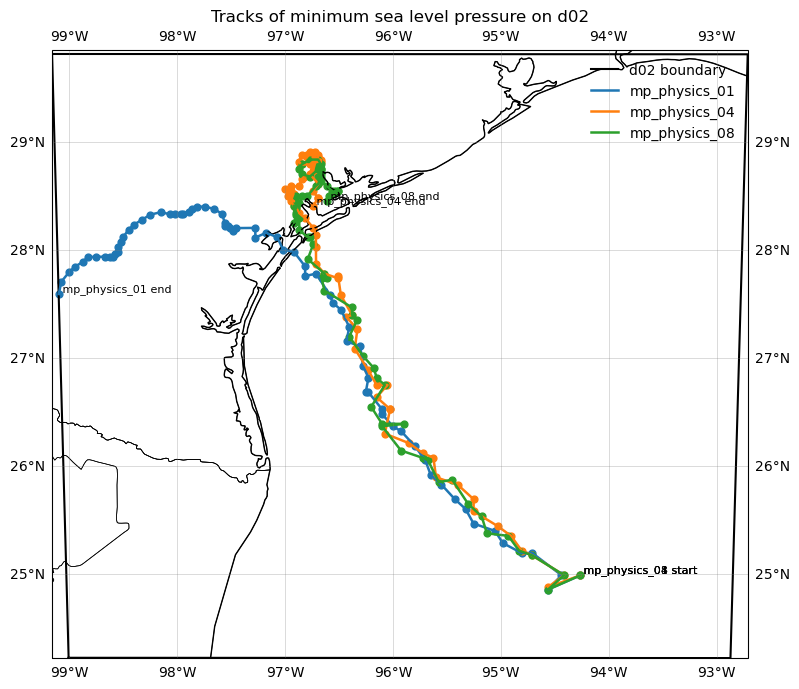

In [8]:
# ---------------- USER SETTINGS ----------------

OUT_DIR = Path.cwd() / "tracks_d02"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "all_min_slp_tracks_d02.png"
# ----------------------------------------------

def get_time_from_filename(path: Path) -> pd.Timestamp:
    """Extract valid time from wrfout filename."""
    return pd.to_datetime(
        path.name.replace("wrfout_d02_", ""),
        format="%Y-%m-%d_%H:%M:%S"
    )


def compute_min_slp_track(wrf_dir: Path, file_glob: str = "wrfout_d02_*"):
    """
    Compute the min-SLP track for one simulation directory.
    Returns:
        df      : DataFrame with time, lat, lon, min_slp_hpa
        lat2d   : 2D latitude array
        lon2d   : 2D longitude array
    """
    files = sorted(wrf_dir.glob(file_glob))
    if not files:
        raise FileNotFoundError(f"No files found matching {file_glob} in {wrf_dir}")

    rows = []

    # Read lat/lon grid from first file
    with Dataset(files[0]) as ds0:
        slp0 = getvar(ds0, "slp", timeidx=0)  # hPa
        lats, lons = latlon_coords(slp0)
        lat2d = np.asarray(lats)
        lon2d = np.asarray(lons)

    for f in files:
        t = get_time_from_filename(f)

        with Dataset(f) as ds:
            slp = getvar(ds, "slp", timeidx=0)  # hPa
            slp2d = np.asarray(slp)

            jmin, imin = np.unravel_index(np.nanargmin(slp2d), slp2d.shape)
            slp_min = float(slp2d[jmin, imin])

            rows.append({
                "time": t,
                "j": int(jmin),
                "i": int(imin),
                "lat": float(lat2d[jmin, imin]),
                "lon": float(lon2d[jmin, imin]),
                "min_slp_hpa": slp_min,
            })

    df = pd.DataFrame(rows).sort_values("time")
    return df, lat2d, lon2d


# ---------------- Compute tracks ----------------
track_dict = {}
domain_lat2d = None
domain_lon2d = None

for label, wrf_dir in SIM_DIRS.items():
    print(f"[INFO] Processing {label}: {wrf_dir}")

    df, lat2d, lon2d = compute_min_slp_track(wrf_dir, FILE_GLOB)
    track_dict[label] = df

    # Save CSV for each simulation
    out_csv = OUT_DIR / f"min_slp_track_{label.replace(' ', '_')}.csv"
    df.to_csv(out_csv, index=False)
    print(f"[OK] Saved {out_csv}")

    # Use first grid for plotting the outer domain boundary
    if domain_lat2d is None:
        domain_lat2d = lat2d
        domain_lon2d = lon2d


# ---------------- Plot all tracks ----------------
fig, ax = plt.subplots(
    figsize=(9, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.coastlines(resolution="10m", linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5)

# Domain boundary (from first simulation)
ax.plot(
    [domain_lon2d[0, 0], domain_lon2d[0, -1], domain_lon2d[-1, -1], domain_lon2d[-1, 0], domain_lon2d[0, 0]],
    [domain_lat2d[0, 0], domain_lat2d[0, -1], domain_lat2d[-1, -1], domain_lat2d[-1, 0], domain_lat2d[0, 0]],
    color="k", linewidth=1.5, label="d02 boundary",
    transform=ccrs.PlateCarree()
)

# Choose distinct colors
colors = {
    "Kessler": "tab:blue",
    "WSM5": "tab:orange",
    "Thompson": "tab:green",
}

for label, df in track_dict.items():
    color = colors.get(label, None)

    # Line
    ax.plot(
        df["lon"], df["lat"],
        color=color, linewidth=1.8, label=label,
        transform=ccrs.PlateCarree()
    )

    # Markers
    ax.scatter(
        df["lon"], df["lat"],
        s=24, color=color,
        transform=ccrs.PlateCarree()
    )

    # Start/end labels
    ax.text(
        df["lon"].iloc[0], df["lat"].iloc[0],
        f" {label} start",
        fontsize=8, va="bottom", color=color,
        transform=ccrs.PlateCarree()
    )
    ax.text(
        df["lon"].iloc[-1], df["lat"].iloc[-1],
        f" {label} end",
        fontsize=8, va="bottom", color=color,
        transform=ccrs.PlateCarree()
    )

# Set extent to domain
ax.set_extent([
    float(domain_lon2d.min()), float(domain_lon2d.max()),
    float(domain_lat2d.min()), float(domain_lat2d.max())
], crs=ccrs.PlateCarree())

ax.set_title("Tracks of minimum sea level pressure on d02")
ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.5)
ax.legend(frameon=False, loc="best")

fig.tight_layout()
fig.savefig(OUT_PNG, dpi=200)
print(f"[OK] Saved {OUT_PNG}")


plt.show()

## Make contour plots of 10-m wind speed

In [10]:


FILE_GLOB = "wrfout_d02_*"
OUT_DIR = Path.cwd() / "wspd10_3panel_d02"
OUT_DIR.mkdir(parents=True, exist_ok=True)

VMIN = 0.0
VMAX = 35.0
NLEVELS = 15
CMAP = "viridis"
DPI = 150
# ----------------------------------------------


def get_2d_field(da):
    arr = da.values
    if arr.ndim == 3:
        return arr[0, :, :]
    elif arr.ndim == 2:
        return arr
    else:
        raise ValueError(f"Unexpected number of dimensions: {arr.ndim}")


def get_latlon(ds):
    if "XLAT" in ds.variables and "XLONG" in ds.variables:
        lat = get_2d_field(ds["XLAT"])
        lon = get_2d_field(ds["XLONG"])
    elif "lat" in ds.variables and "lon" in ds.variables:
        lat = get_2d_field(ds["lat"])
        lon = get_2d_field(ds["lon"])
    else:
        raise KeyError("Could not find XLAT/XLONG or lat/lon in dataset.")
    return lat, lon


def get_wspd10(ds):
    u10 = get_2d_field(ds["U10"])
    v10 = get_2d_field(ds["V10"])
    return np.sqrt(u10**2 + v10**2)


def build_common_file_dict(sim_dirs, file_glob):
    """Return dict of files by sim and sorted list of filenames common to all sims."""
    files_by_sim = {}
    for label, sim_dir in sim_dirs.items():
        files = sorted(sim_dir.glob(file_glob))
        files_by_sim[label] = {f.name: f for f in files}
        print(f"[OK] {label}: found {len(files)} files")

    common_names = sorted(set.intersection(*(set(d.keys()) for d in files_by_sim.values())))
    print(f"[OK] Found {len(common_names)} common files across all simulations")
    return files_by_sim, common_names


def plot_wspd10_threepanel_for_time(
    fname,
    files_by_sim,
    out_dir,
    vmin=0.0,
    vmax=35.0,
    nlevels=15,
    cmap="viridis",
    dpi=150,
    show=True,
):
    """
    Make one 3-panel plot for a specific wrfout filename, e.g.
    fname = 'wrfout_d02_2017-08-25_12:00:00'
    """
    valid_time = fname.split("_", 2)[2]   # keeps YYYY-MM-DD_HH:MM:SS
    out_png = out_dir / f"wspd10_3panel_{valid_time}.png"
    levels = np.linspace(vmin, vmax, nlevels)

    fig, axs = plt.subplots(
        1, 3, figsize=(16, 5),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True
    )

    mappable = None
    map_extent = None

    for ax, (label, _) in zip(axs, files_by_sim.items()):
        fpath = files_by_sim[label][fname]

        with xr.open_dataset(fpath, engine="netcdf4") as ds:
            wspd10 = get_wspd10(ds)
            lat, lon = get_latlon(ds)

            if map_extent is None:
                map_extent = [
                    float(np.nanmin(lon)), float(np.nanmax(lon)),
                    float(np.nanmin(lat)), float(np.nanmax(lat)),
                ]

            mappable = ax.contourf(
                lon, lat, wspd10,
                levels=levels, cmap=cmap, extend="max",
                transform=ccrs.PlateCarree()
            )

        ax.coastlines(resolution="10m", linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.add_feature(cfeature.STATES, linewidth=0.5)

        ax.set_extent(map_extent, crs=ccrs.PlateCarree())
        ax.set_title(label)

        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            linewidth=0.4,
            color="gray",
            alpha=0.5,
            linestyle="--"
        )
        gl.top_labels = False
        gl.right_labels = False

    fig.suptitle(f"WRF d02 10-m wind speed\nValid time: {valid_time}", y=1.03)

    cbar = fig.colorbar(mappable, ax=axs, orientation="vertical", shrink=0.9, pad=0.02)
    cbar.set_label("10-m wind speed [m s$^{-1}$]")

    fig.savefig(out_png, dpi=dpi, bbox_inches="tight")
    print(f"[OK] Saved {out_png}")

    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_wspd10_threepanel(
    requested_time=None,
    make_all=False,
    show=True,
):
    """
    requested_time can be:
      '2017-08-25_12:00:00'
    or
      'wrfout_d02_2017-08-25_12:00:00'

    If make_all=True, makes plots for all common times.
    """
    files_by_sim, common_names = build_common_file_dict(SIM_DIRS, FILE_GLOB)

    if make_all:
        for fname in common_names:
            plot_wspd10_threepanel_for_time(
                fname=fname,
                files_by_sim=files_by_sim,
                out_dir=OUT_DIR,
                vmin=VMIN,
                vmax=VMAX,
                nlevels=NLEVELS,
                cmap=CMAP,
                dpi=DPI,
                show=show,
            )
        return

    if requested_time is None:
        raise ValueError("Provide requested_time or set make_all=True")

    if not requested_time.startswith("wrfout_d02_"):
        fname = f"wrfout_d02_{requested_time}"
    else:
        fname = requested_time

    if fname not in common_names:
        raise ValueError(
            f"{fname} not found in common files.\n"
            f"Example available time: {common_names[0] if common_names else 'none'}"
        )

    plot_wspd10_threepanel_for_time(
        fname=fname,
        files_by_sim=files_by_sim,
        out_dir=OUT_DIR,
        vmin=VMIN,
        vmax=VMAX,
        nlevels=NLEVELS,
        cmap=CMAP,
        dpi=DPI,
        show=show,
    )

[OK] mp_physics_01: found 73 files
[OK] mp_physics_04: found 73 files
[OK] mp_physics_08: found 73 files
[OK] Found 73 common files across all simulations
[OK] Saved /home/jlundqui/EN530.462/AtmosphericModelingLab/ICA10/wspd10_3panel_d02/wspd10_3panel_2017-08-27_00:00:00.png


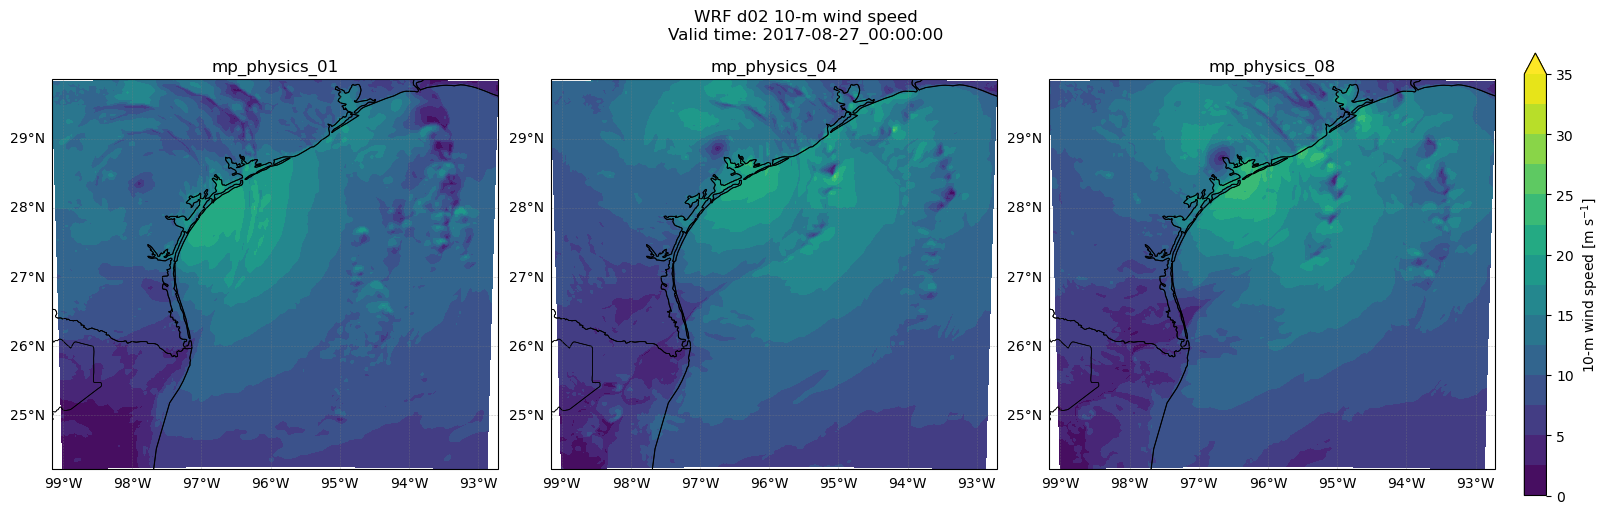

In [12]:
plot_wspd10_threepanel(requested_time="2017-08-27_00:00:00", show=True)

In [13]:
FILE_GLOB = "wrfout_d02_*"
OUT_DIR = Path.cwd() / "precip_3panel_d02"
OUT_DIR.mkdir(parents=True, exist_ok=True)

VMIN = 0.0
VMAX = 500.0
NLEVELS = 21
CMAP = "Blues"
DPI = 150
# ----------------------------------------------


def get_2d_field(da):
    arr = da.values
    if arr.ndim == 3:
        return arr[0, :, :]
    elif arr.ndim == 2:
        return arr
    else:
        raise ValueError(f"Unexpected number of dimensions: {arr.ndim}")


def get_latlon(ds):
    if "XLAT" in ds.variables and "XLONG" in ds.variables:
        lat = get_2d_field(ds["XLAT"])
        lon = get_2d_field(ds["XLONG"])
    elif "lat" in ds.variables and "lon" in ds.variables:
        lat = get_2d_field(ds["lat"])
        lon = get_2d_field(ds["lon"])
    else:
        raise KeyError("Could not find XLAT/XLONG or lat/lon in dataset.")
    return lat, lon


def get_accum_precip(ds):
    """Return accumulated precip [mm] = RAINC + RAINNC."""
    rainc = get_2d_field(ds["RAINC"])
    rainnc = get_2d_field(ds["RAINNC"])
    return rainc + rainnc


def build_common_file_dict(sim_dirs, file_glob):
    files_by_sim = {}
    for label, sim_dir in sim_dirs.items():
        files = sorted(sim_dir.glob(file_glob))
        files_by_sim[label] = {f.name: f for f in files}
        print(f"[OK] {label}: found {len(files)} files")

    common_names = sorted(set.intersection(*(set(d.keys()) for d in files_by_sim.values())))
    print(f"[OK] Found {len(common_names)} common files across all simulations")
    return files_by_sim, common_names


def plot_precip_threepanel_for_time(
    fname,
    files_by_sim,
    out_dir,
    vmin=0.0,
    vmax=500.0,
    nlevels=21,
    cmap="Blues",
    dpi=150,
    show=True,
):
    """
    Make one 3-panel plot for a specific wrfout filename, e.g.
    fname = 'wrfout_d02_2017-08-25_12:00:00'
    """
    valid_time = fname.split("_", 2)[2]
    out_png = out_dir / f"precip_3panel_{valid_time}.png"
    levels = np.linspace(vmin, vmax, nlevels)

    fig, axs = plt.subplots(
        1, 3, figsize=(16, 5),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True
    )

    mappable = None
    map_extent = None

    for ax, (label, _) in zip(axs, files_by_sim.items()):
        fpath = files_by_sim[label][fname]

        with xr.open_dataset(fpath, engine="netcdf4") as ds:
            precip = get_accum_precip(ds)
            lat, lon = get_latlon(ds)

            if map_extent is None:
                map_extent = [
                    float(np.nanmin(lon)), float(np.nanmax(lon)),
                    float(np.nanmin(lat)), float(np.nanmax(lat)),
                ]

            mappable = ax.contourf(
                lon, lat, precip,
                levels=levels, cmap=cmap, extend="max",
                transform=ccrs.PlateCarree()
            )

        ax.coastlines(resolution="10m", linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.add_feature(cfeature.STATES, linewidth=0.5)

        ax.set_extent(map_extent, crs=ccrs.PlateCarree())
        ax.set_title(label)

        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            linewidth=0.4,
            color="gray",
            alpha=0.5,
            linestyle="--"
        )
        gl.top_labels = False
        gl.right_labels = False

    fig.suptitle(
        f"WRF d02 accumulated precipitation (RAINC + RAINNC)\nValid time: {valid_time}",
        y=1.03
    )

    cbar = fig.colorbar(mappable, ax=axs, orientation="vertical", shrink=0.9, pad=0.02)
    cbar.set_label("Accumulated precipitation [mm]")

    fig.savefig(out_png, dpi=dpi, bbox_inches="tight")
    print(f"[OK] Saved {out_png}")

    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_precip_threepanel(
    requested_time=None,
    make_all=False,
    show=True,
):
    """
    requested_time can be:
      '2017-08-25_12:00:00'
    or
      'wrfout_d02_2017-08-25_12:00:00'

    If make_all=True, makes plots for all common times.
    """
    files_by_sim, common_names = build_common_file_dict(SIM_DIRS, FILE_GLOB)

    if make_all:
        for fname in common_names:
            plot_precip_threepanel_for_time(
                fname=fname,
                files_by_sim=files_by_sim,
                out_dir=OUT_DIR,
                vmin=VMIN,
                vmax=VMAX,
                nlevels=NLEVELS,
                cmap=CMAP,
                dpi=DPI,
                show=show,
            )
        return

    if requested_time is None:
        raise ValueError("Provide requested_time or set make_all=True")

    if not requested_time.startswith("wrfout_d02_"):
        fname = f"wrfout_d02_{requested_time}"
    else:
        fname = requested_time

    if fname not in common_names:
        raise ValueError(
            f"{fname} not found in common files.\n"
            f"Example available time: {common_names[0] if common_names else 'none'}"
        )

    plot_precip_threepanel_for_time(
        fname=fname,
        files_by_sim=files_by_sim,
        out_dir=OUT_DIR,
        vmin=VMIN,
        vmax=VMAX,
        nlevels=NLEVELS,
        cmap=CMAP,
        dpi=DPI,
        show=show,
    )

[OK] mp_physics_01: found 73 files
[OK] mp_physics_04: found 73 files
[OK] mp_physics_08: found 73 files
[OK] Found 73 common files across all simulations
[OK] Saved /home/jlundqui/EN530.462/AtmosphericModelingLab/ICA10/precip_3panel_d02/precip_3panel_2017-08-28_00:00:00.png


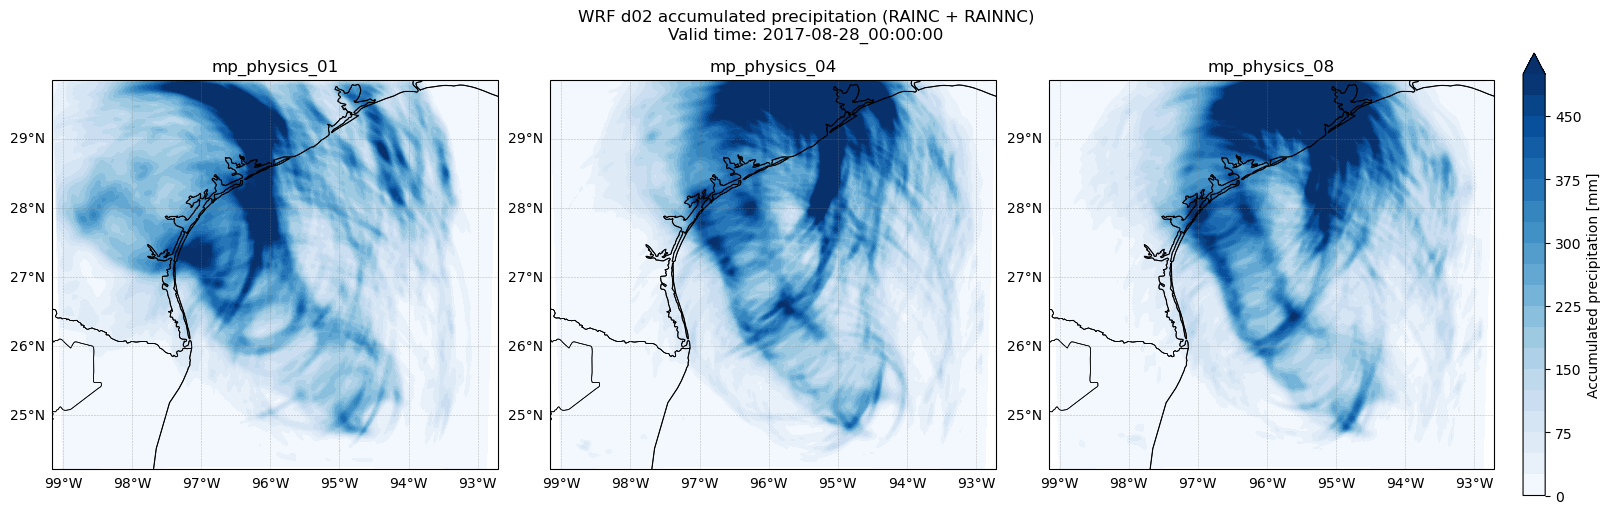

In [14]:
plot_precip_threepanel(requested_time="2017-08-28_00:00:00", show=True)